<a href="https://colab.research.google.com/github/mmbc560/GUIA2/blob/main/Ejemplos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OUTSOURCED CLEANING SERVICES

BUSINESS PROBLEM:

The organization wants to improve the operational and
sustainability performance of outsourced cleaning services.

MANAGERIAL QUESTION:

Which operational and supplier-management factors are associated
with better service performance?

ONE ROW:

One simulated service observation or inspection.


FIRST 10 SERVICE OBSERVATIONS:
   Supplier_Reliability  Training_Level  Response_Time  Resource_Efficiency  \
0                     4               4             38                    1   
1                     5               1             10                    4   
2                     3               4             26                    3   
3                     5               2             15                    3   
4                     5               1             52                    5   
5                     2               5             20                    3   
6                     3               3             37                

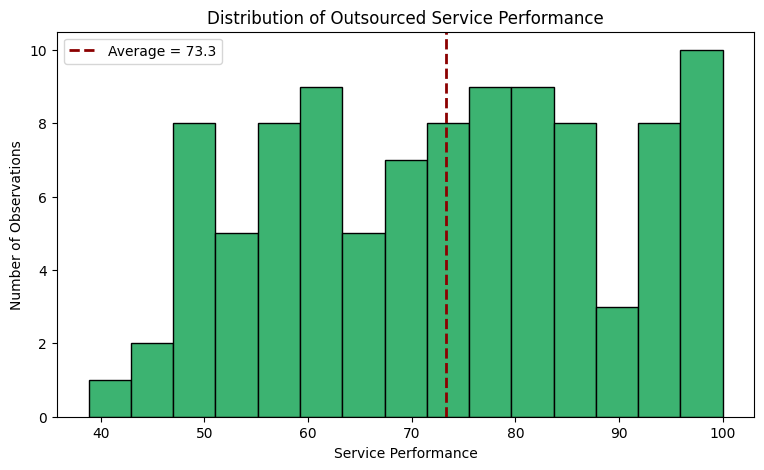


GRAPH 1:

Look beyond the average.

Are service observations concentrated around similar values,
or is there substantial variability?

OPERATIONAL EXCELLENCE QUESTION:

Is the outsourced process consistently delivering the expected
service level?



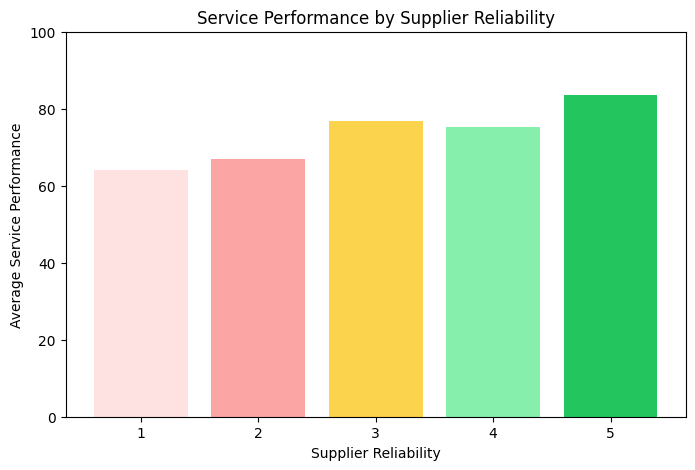


GRAPH 2:

Compare performance at different supplier-reliability levels.

If performance improves with reliability, supplier management
becomes an important Operational Excellence issue.

QUESTION:

Should supplier reliability become part of the SLA or
supplier-performance scorecard?



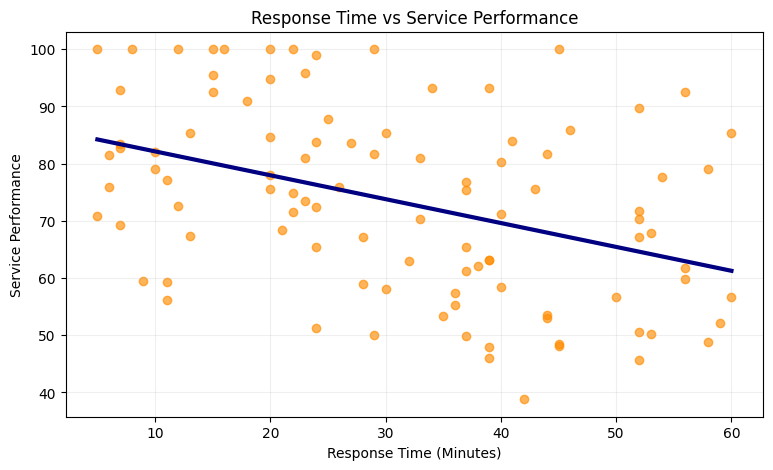


GRAPH 3:

The downward trend suggests that longer response times are
associated with lower service performance in the simulated data.

This finding could motivate:

• Process-flow analysis
• Waste identification
• SLA review
• Staffing analysis
• Lean improvement



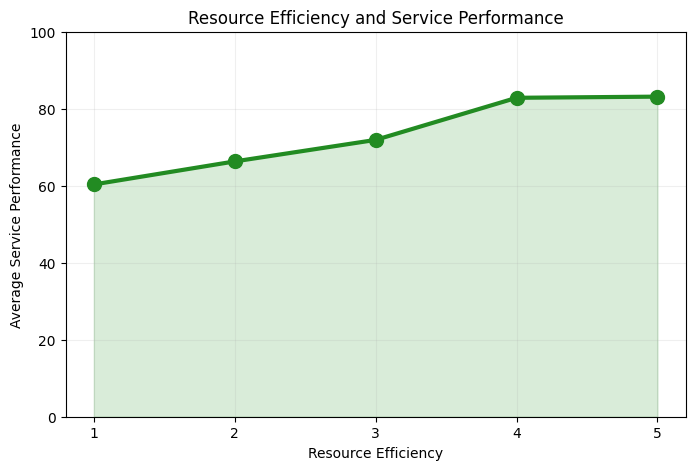


GRAPH 4:

This graph connects Operational Excellence with Sustainability.

Higher resource efficiency represents better use of resources
such as water, chemicals and materials.

The managerial objective should not necessarily be:

SERVICE OR SUSTAINABILITY.

A stronger question is:

Can the organization improve SERVICE AND RESOURCE EFFICIENCY
simultaneously?



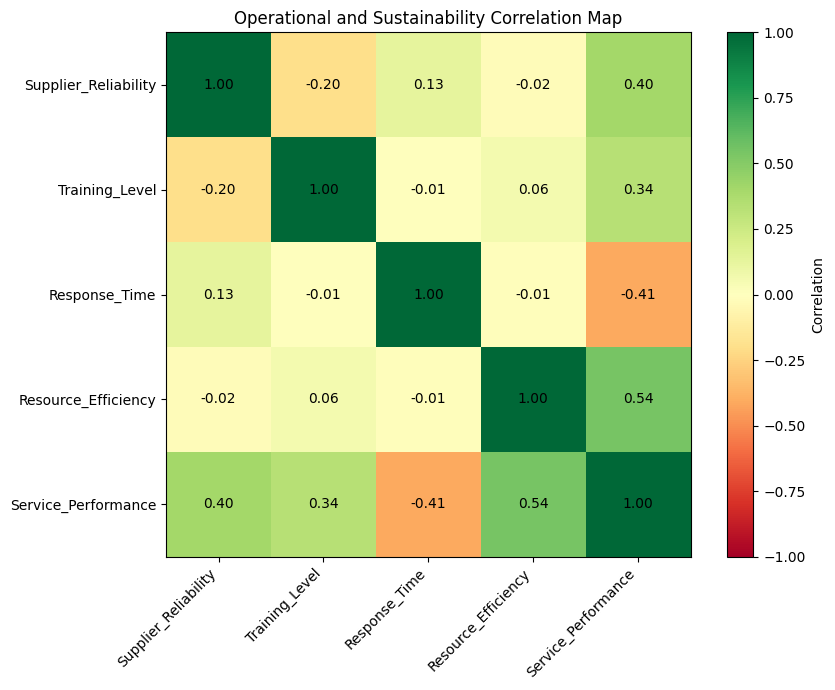


CORRELATIONS WITH SERVICE PERFORMANCE:
Service_Performance     1.00
Resource_Efficiency     0.54
Supplier_Reliability    0.40
Training_Level          0.34
Response_Time          -0.41
Name: Service_Performance, dtype: float64

R² = 0.836

STANDARDIZED REGRESSION RESULTS:
               Variable  Standardized_Coefficient  Absolute_Effect
0  Supplier_Reliability                     0.552            0.552
3   Resource_Efficiency                     0.525            0.525
2         Response_Time                    -0.469            0.469
1        Training_Level                     0.413            0.413


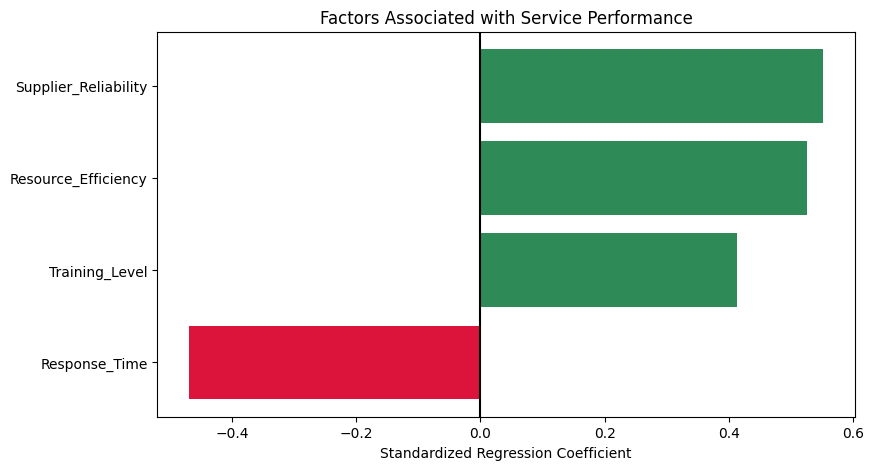


GRAPH 5:

GREEN:
Factors positively associated with service performance.

RED:
Factors negatively associated with service performance.

The standardized coefficients help us compare the relative
strength of the associations because the original variables
use different measurement scales.

IMPORTANT:
This is NOT proof of causality.


MANAGERIAL INTERPRETATION
Supplier_Reliability: improving/increasing this factor is associated with HIGHER service performance.
Resource_Efficiency: improving/increasing this factor is associated with HIGHER service performance.
Response_Time: higher values are associated with LOWER service performance.
Training_Level: improving/increasing this factor is associated with HIGHER service performance.

POSSIBLE IMPROVEMENT ALTERNATIVES:
                                   Alternative              Methodology                                                            Main_Focus
            A1 - Lean Service Flow Improvement                     Lean              

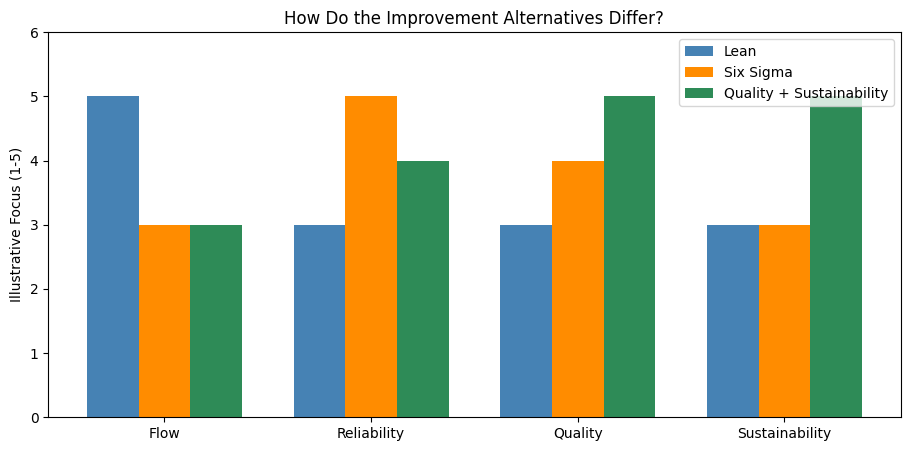


FROM ANALYTICS TO DECISION MAKING

STEP 1 - DESCRIPTIVE ANALYTICS
We understood current simulated performance and variability.

STEP 2 - CORRELATION
We explored relationships among variables.

STEP 3 - REGRESSION
We identified factors associated with Service Performance.

STEP 4 - OPERATIONAL EXCELLENCE
We transformed possible drivers into improvement alternatives:

A1 → Lean
A2 → Six Sigma
A3 → Quality + Sustainability

BUT...

Which alternative should management prioritize?

Regression cannot answer that question because management
must consider MORE THAN ONE CRITERION.

Possible criteria:

1. Expected Operational Impact
2. Implementation Cost
3. Implementation Time
4. Ease of Implementation
5. Sustainability Contribution

NEXT ANALYTICAL TOOL:

AHP - ANALYTIC HIERARCHY PROCESS



In [1]:
# =====================================================================
# TEAM 3 - OUTSOURCED CLEANING SERVICES
# =====================================================================
#
# Y = Service_Performance
#
# X1 = Supplier_Reliability
# X2 = Training_Level
# X3 = Response_Time
# X4 = Resource_Efficiency
#
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score


# =====================================================================
# 1. BUSINESS PROBLEM
# =====================================================================

print("=" * 75)
print("OUTSOURCED CLEANING SERVICES")
print("=" * 75)

print("""
BUSINESS PROBLEM:

The organization wants to improve the operational and
sustainability performance of outsourced cleaning services.

MANAGERIAL QUESTION:

Which operational and supplier-management factors are associated
with better service performance?

ONE ROW:

One simulated service observation or inspection.
""")


# =====================================================================
# 2. SIMULATED DATA
# =====================================================================

np.random.seed(42)

n = 100


# Supplier reliability: 1-5
supplier_reliability = np.random.randint(1, 6, n)


# Training level: 1-5
training = np.random.randint(1, 6, n)


# Response time: 5-60 minutes
response_time = np.random.randint(5, 61, n)


# Resource efficiency: 1-5
resource_efficiency = np.random.randint(1, 6, n)


# =====================================================================
# 3. CREATE SERVICE PERFORMANCE
# =====================================================================
#
# Reliability ↑         → Performance ↑
# Training ↑            → Performance ↑
# Response Time ↑       → Performance ↓
# Resource Efficiency ↑ → Performance ↑
#
# =====================================================================

performance = (
    35
    + 7 * supplier_reliability
    + 5 * training
    - 0.5 * response_time
    + 6 * resource_efficiency
    + np.random.normal(0, 6, n)
)

performance = np.clip(
    performance,
    0,
    100
)


# =====================================================================
# 4. DATABASE
# =====================================================================

df = pd.DataFrame({

    "Supplier_Reliability": supplier_reliability,

    "Training_Level": training,

    "Response_Time": response_time,

    "Resource_Efficiency": resource_efficiency,

    "Service_Performance": performance
})


print("\nFIRST 10 SERVICE OBSERVATIONS:")
print(df.head(10).round(2))


# =====================================================================
# 5. DESCRIPTIVE STATISTICS
# =====================================================================

print("\nDESCRIPTIVE STATISTICS:")
print(df.describe().round(2))

mean_y = df["Service_Performance"].mean()
std_y = df["Service_Performance"].std()

print(f"\nAverage Service Performance = {mean_y:.1f}")
print(f"Standard Deviation = {std_y:.1f}")


print("""
INTERPRETATION:

Average performance tells us the general service level.

Standard deviation tells us about CONSISTENCY.

An outsourced service could have a reasonable average but still
have operational problems if performance is highly variable.
""")


# =====================================================================
# 6. GRAPH 1 - SERVICE PERFORMANCE DISTRIBUTION
# =====================================================================

plt.figure(figsize=(9, 5))

plt.hist(
    df["Service_Performance"],
    bins=15,
    color="mediumseagreen",
    edgecolor="black"
)

plt.axvline(
    mean_y,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Average = {mean_y:.1f}"
)

plt.title("Distribution of Outsourced Service Performance")
plt.xlabel("Service Performance")
plt.ylabel("Number of Observations")
plt.legend()

plt.show()


print("""
GRAPH 1:

Look beyond the average.

Are service observations concentrated around similar values,
or is there substantial variability?

OPERATIONAL EXCELLENCE QUESTION:

Is the outsourced process consistently delivering the expected
service level?
""")


# =====================================================================
# 7. GRAPH 2 - SUPPLIER RELIABILITY
# =====================================================================

supplier_summary = (
    df.groupby("Supplier_Reliability")["Service_Performance"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    supplier_summary.index,
    supplier_summary.values,
    color=["#FEE2E2", "#FCA5A5", "#FCD34D", "#86EFAC", "#22C55E"]
)

plt.title("Service Performance by Supplier Reliability")
plt.xlabel("Supplier Reliability")
plt.ylabel("Average Service Performance")
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, 100)

plt.show()


print("""
GRAPH 2:

Compare performance at different supplier-reliability levels.

If performance improves with reliability, supplier management
becomes an important Operational Excellence issue.

QUESTION:

Should supplier reliability become part of the SLA or
supplier-performance scorecard?
""")


# =====================================================================
# 8. GRAPH 3 - RESPONSE TIME VS PERFORMANCE
# =====================================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    df["Response_Time"],
    df["Service_Performance"],
    color="darkorange",
    alpha=0.65
)

z = np.polyfit(
    df["Response_Time"],
    df["Service_Performance"],
    1
)

p = np.poly1d(z)

x_line = np.linspace(
    df["Response_Time"].min(),
    df["Response_Time"].max(),
    100
)

plt.plot(
    x_line,
    p(x_line),
    color="navy",
    linewidth=3
)

plt.title("Response Time vs Service Performance")
plt.xlabel("Response Time (Minutes)")
plt.ylabel("Service Performance")
plt.grid(alpha=0.2)

plt.show()


print("""
GRAPH 3:

The downward trend suggests that longer response times are
associated with lower service performance in the simulated data.

This finding could motivate:

• Process-flow analysis
• Waste identification
• SLA review
• Staffing analysis
• Lean improvement
""")


# =====================================================================
# 9. GRAPH 4 - SUSTAINABILITY CONNECTION
# =====================================================================

resource_summary = (
    df.groupby("Resource_Efficiency")["Service_Performance"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    resource_summary.index,
    resource_summary.values,
    marker="o",
    markersize=10,
    linewidth=3,
    color="forestgreen"
)

plt.fill_between(
    resource_summary.index,
    resource_summary.values,
    alpha=0.15,
    color="green"
)

plt.title("Resource Efficiency and Service Performance")
plt.xlabel("Resource Efficiency")
plt.ylabel("Average Service Performance")
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, 100)
plt.grid(alpha=0.2)

plt.show()


print("""
GRAPH 4:

This graph connects Operational Excellence with Sustainability.

Higher resource efficiency represents better use of resources
such as water, chemicals and materials.

The managerial objective should not necessarily be:

SERVICE OR SUSTAINABILITY.

A stronger question is:

Can the organization improve SERVICE AND RESOURCE EFFICIENCY
simultaneously?
""")


# =====================================================================
# 10. CORRELATION HEATMAP
# =====================================================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))

plt.imshow(
    corr,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr.columns)):

    for j in range(len(corr.columns)):

        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Operational and Sustainability Correlation Map")
plt.tight_layout()

plt.show()


print("\nCORRELATIONS WITH SERVICE PERFORMANCE:")

print(
    corr["Service_Performance"]
    .sort_values(ascending=False)
    .round(2)
)


# =====================================================================
# 11. REGRESSION
# =====================================================================

X = df[
    [
        "Supplier_Reliability",
        "Training_Level",
        "Response_Time",
        "Resource_Efficiency"
    ]
]

y = df["Service_Performance"]


model = LinearRegression()

model.fit(X, y)

prediction = model.predict(X)


print(f"\nR² = {r2_score(y, prediction):.3f}")


# =====================================================================
# 12. STANDARDIZED REGRESSION
# =====================================================================

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X)

y_scaled = scaler_y.fit_transform(
    y.values.reshape(-1, 1)
).ravel()


model_scaled = LinearRegression()

model_scaled.fit(
    X_scaled,
    y_scaled
)


results = pd.DataFrame({

    "Variable": X.columns,

    "Standardized_Coefficient": model_scaled.coef_
})


results["Absolute_Effect"] = (
    results["Standardized_Coefficient"].abs()
)


results = results.sort_values(
    "Absolute_Effect",
    ascending=False
)


print("\nSTANDARDIZED REGRESSION RESULTS:")
print(results.round(3))


# =====================================================================
# 13. GRAPH 5 - WHAT MATTERS MOST?
# =====================================================================

plot_results = results.sort_values(
    "Standardized_Coefficient"
)

colors = [
    "crimson" if x < 0 else "seagreen"
    for x in plot_results["Standardized_Coefficient"]
]

plt.figure(figsize=(9, 5))

plt.barh(
    plot_results["Variable"],
    plot_results["Standardized_Coefficient"],
    color=colors
)

plt.axvline(
    0,
    color="black"
)

plt.title("Factors Associated with Service Performance")
plt.xlabel("Standardized Regression Coefficient")

plt.show()


print("""
GRAPH 5:

GREEN:
Factors positively associated with service performance.

RED:
Factors negatively associated with service performance.

The standardized coefficients help us compare the relative
strength of the associations because the original variables
use different measurement scales.

IMPORTANT:
This is NOT proof of causality.
""")


# =====================================================================
# 14. AUTOMATIC MANAGERIAL INTERPRETATION
# =====================================================================

print("\n" + "=" * 75)
print("MANAGERIAL INTERPRETATION")
print("=" * 75)


for _, row in results.iterrows():

    variable = row["Variable"]

    coefficient = row["Standardized_Coefficient"]

    if coefficient > 0:

        print(
            f"{variable}: improving/increasing this factor is "
            "associated with HIGHER service performance."
        )

    else:

        print(
            f"{variable}: higher values are associated with "
            "LOWER service performance."
        )


# =====================================================================
# 15. THREE IMPROVEMENT ALTERNATIVES
# =====================================================================

alternatives = pd.DataFrame({

    "Alternative": [

        "A1 - Lean Service Flow Improvement",

        "A2 - Six Sigma Service Reliability Program",

        "A3 - Quality & Sustainable Supplier Management"
    ],

    "Methodology": [

        "Lean",

        "Six Sigma",

        "Quality + Sustainability"
    ],

    "Main_Focus": [

        "Reduce waiting, unnecessary activities and response time",

        "Reduce variability, incidents and SLA failures using DMAIC",

        "Strengthen supplier standards, training, KPIs and resource efficiency"
    ]
})


print("\nPOSSIBLE IMPROVEMENT ALTERNATIVES:")

print(
    alternatives.to_string(index=False)
)


# =====================================================================
# 16. GRAPH 6 - ALTERNATIVE PROFILES
# =====================================================================
#
# THESE ARE NOT AHP SCORES.
#
# They simply illustrate why the alternatives are different.
# =====================================================================

dimensions = [
    "Flow",
    "Reliability",
    "Quality",
    "Sustainability"
]

lean = [5, 3, 3, 3]

six_sigma = [3, 5, 4, 3]

quality_sustainability = [3, 4, 5, 5]


x = np.arange(
    len(dimensions)
)

width = 0.25


plt.figure(figsize=(11, 5))


plt.bar(
    x - width,
    lean,
    width,
    label="Lean",
    color="steelblue"
)


plt.bar(
    x,
    six_sigma,
    width,
    label="Six Sigma",
    color="darkorange"
)


plt.bar(
    x + width,
    quality_sustainability,
    width,
    label="Quality + Sustainability",
    color="seagreen"
)


plt.xticks(
    x,
    dimensions
)

plt.ylabel(
    "Illustrative Focus (1-5)"
)

plt.title(
    "How Do the Improvement Alternatives Differ?"
)

plt.legend()

plt.ylim(
    0,
    6
)

plt.show()


# =====================================================================
# 17. FINAL TRANSITION TO AHP
# =====================================================================

print("""
===============================================================
FROM ANALYTICS TO DECISION MAKING
===============================================================

STEP 1 - DESCRIPTIVE ANALYTICS
We understood current simulated performance and variability.

STEP 2 - CORRELATION
We explored relationships among variables.

STEP 3 - REGRESSION
We identified factors associated with Service Performance.

STEP 4 - OPERATIONAL EXCELLENCE
We transformed possible drivers into improvement alternatives:

A1 → Lean
A2 → Six Sigma
A3 → Quality + Sustainability

BUT...

Which alternative should management prioritize?

Regression cannot answer that question because management
must consider MORE THAN ONE CRITERION.

Possible criteria:

1. Expected Operational Impact
2. Implementation Cost
3. Implementation Time
4. Ease of Implementation
5. Sustainability Contribution

NEXT ANALYTICAL TOOL:

AHP - ANALYTIC HIERARCHY PROCESS
===============================================================
""")

CONSULTING & RESEARCH NETWORKING

BUSINESS PROBLEM:
The organization has limited networking with specialized research
groups and needs to identify potential collaboration opportunities.

MANAGERIAL QUESTION:
Which characteristics are associated with greater
collaboration potential?

ONE ROW:
One potential collaboration opportunity.


FIRST 10 OBSERVATIONS:
   Research_Affinity  Previous_Interactions  Knowledge_Complementarity  \
0                  4                      6                          4   
1                  5                      8                          3   
2                  3                      7                          3   
3                  5                      1                          1   
4                  5                      0                          5   
5                  2                      6                          4   
6                  3                      6                          2   
7                  3                      7      

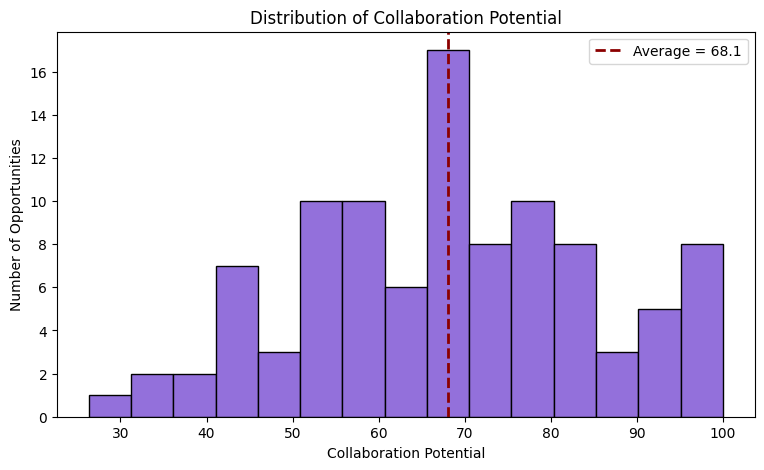


GRAPH 1:

Are all collaboration opportunities similar?

If the distribution is wide, the answer is probably no.

MANAGERIAL IMPLICATION:
A differentiated relationship-management strategy may be
more appropriate than treating all potential partners equally.



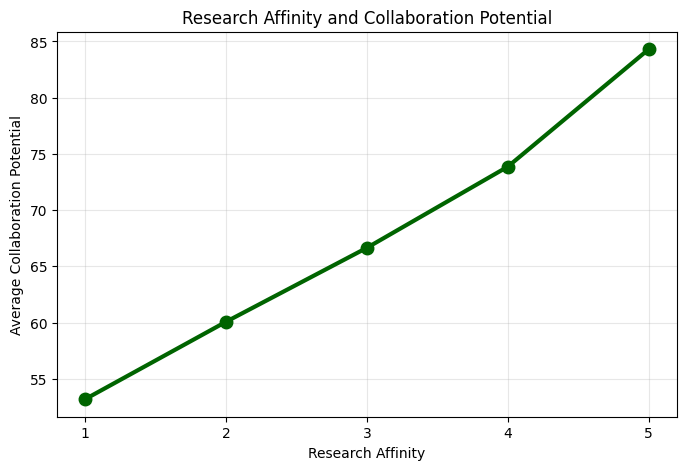


GRAPH 2:

Observe whether collaboration potential increases as
Research Affinity increases.

QUESTION:
Should the organization dedicate the same networking effort
to low-affinity and high-affinity relationships?



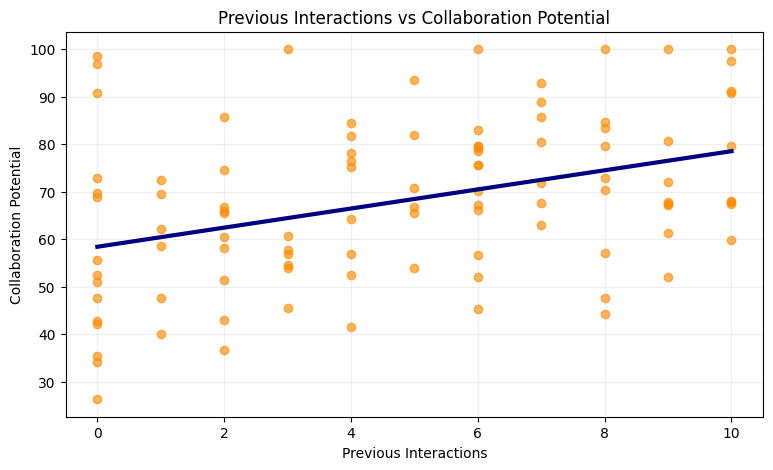


GRAPH 3:

The trend helps us explore whether previous interactions are
associated with collaboration potential.

This could lead to a process question:

Is the organization systematically following up its contacts,
or are networking interactions isolated activities?



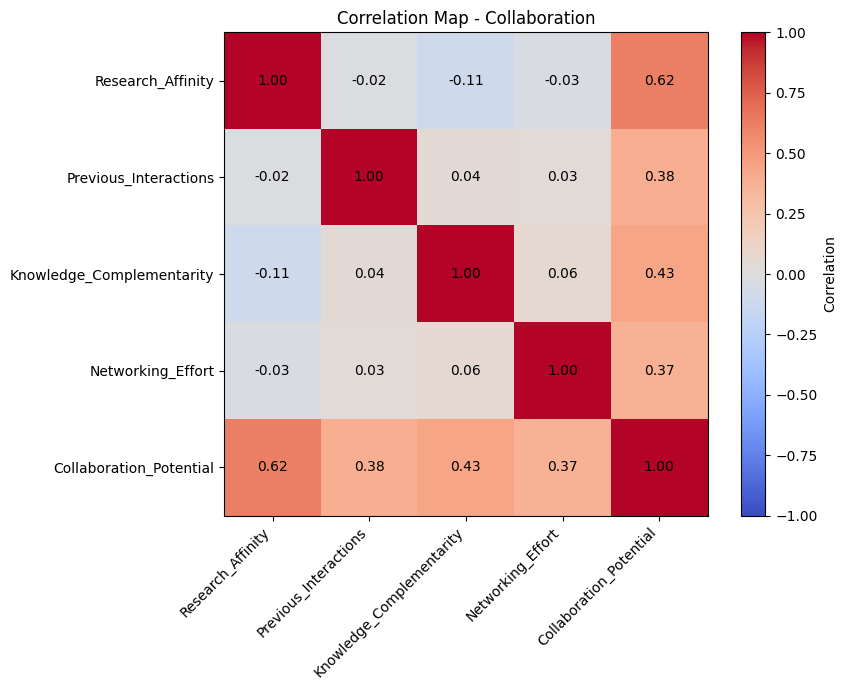


CORRELATIONS WITH COLLABORATION POTENTIAL:
Collaboration_Potential      1.00
Research_Affinity            0.62
Knowledge_Complementarity    0.43
Previous_Interactions        0.38
Networking_Effort            0.37
Name: Collaboration_Potential, dtype: float64

R² = 0.899

STANDARDIZED REGRESSION RESULTS:
                    Variable  Standardized_Coefficient  Absolute_Effect
0          Research_Affinity                     0.686            0.686
2  Knowledge_Complementarity                     0.469            0.469
1      Previous_Interactions                     0.368            0.368
3          Networking_Effort                     0.351            0.351


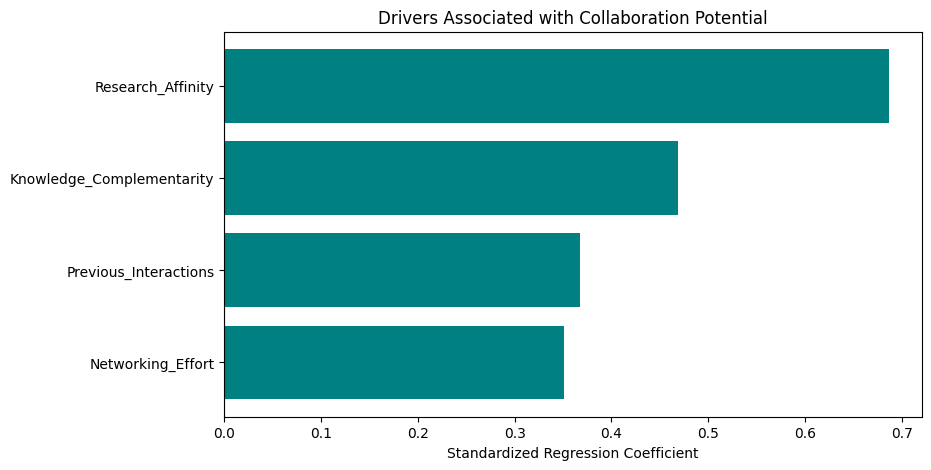


GRAPH 4:

Longer bars represent stronger associations within the
simulated model.

The analytical question is now becoming managerial:

Which of these drivers can the organization ACTUALLY influence?

For example:
Research affinity may be a characteristic to IDENTIFY.

Networking effort may be something management can CHANGE.

That distinction is very important.



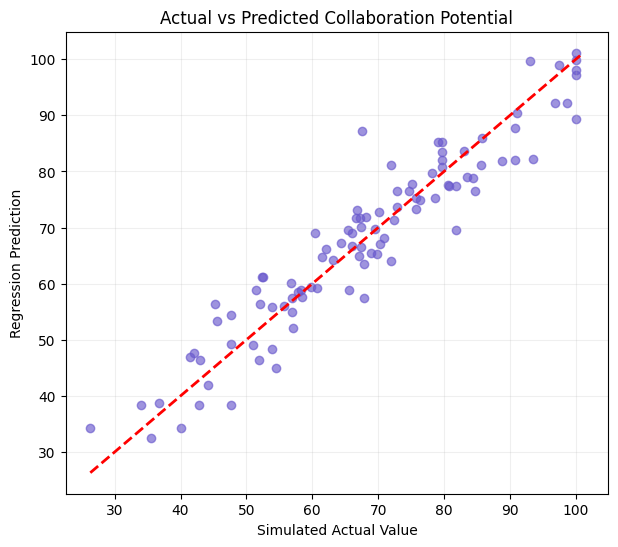


GRAPH 5:

Points closer to the diagonal indicate predictions closer
to the simulated observed values.

Remember:
The objective here is not to create a perfect predictive model.

The objective is to understand how analytical evidence can
support managerial decisions.


POSSIBLE IMPROVEMENT ALTERNATIVES:
                                Alternative           Approach                                                               Focus
               A1 - Lean Networking Process               Lean  Standardize the networking flow and eliminate low-value activities
    A2 - Six Sigma Relationship Development          Six Sigma Reduce variability in the conversion from contacts to collaboration
A3 - Quality-Based Collaboration Management Quality Management Create partner criteria, follow-up standards and collaboration KPIs


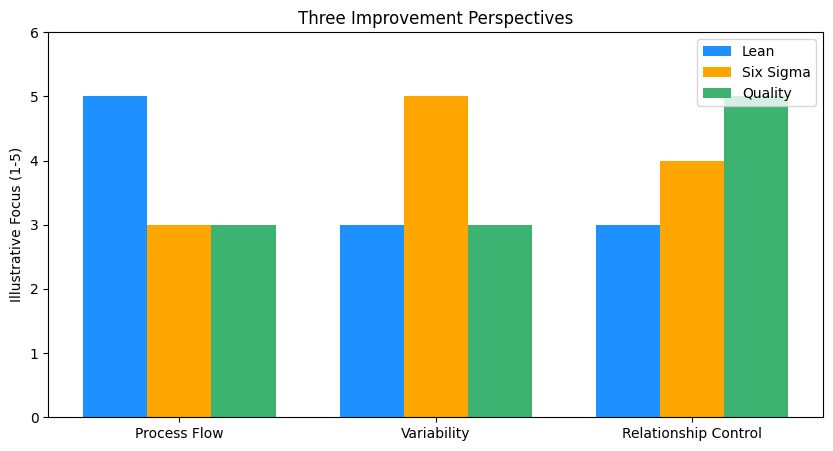


FINAL INTERPRETATION:

Analytics helped us understand possible drivers of collaboration.

Operational Excellence helps us transform those findings into
possible ACTIONS.

But the three alternatives involve different strengths,
costs and implementation requirements.

NEXT QUESTION:

Which alternative should be prioritized?

→ AHP



In [2]:
# =====================================================================
# TEAM 2 - CONSULTING & RESEARCH NETWORKING
# =====================================================================
#
# ONE ROW = One potential collaboration opportunity
#
# Y = Collaboration_Potential
#
# X:
# Research_Affinity
# Previous_Interactions
# Knowledge_Complementarity
# Networking_Effort
#
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score


# =====================================================================
# 1. BUSINESS PROBLEM
# =====================================================================

print("=" * 75)
print("CONSULTING & RESEARCH NETWORKING")
print("=" * 75)

print("""
BUSINESS PROBLEM:
The organization has limited networking with specialized research
groups and needs to identify potential collaboration opportunities.

MANAGERIAL QUESTION:
Which characteristics are associated with greater
collaboration potential?

ONE ROW:
One potential collaboration opportunity.
""")


# =====================================================================
# 2. SIMULATE 100 POTENTIAL COLLABORATIONS
# =====================================================================

np.random.seed(42)

n = 100

research_affinity = np.random.randint(1, 6, n)

previous_interactions = np.random.randint(0, 11, n)

knowledge_complementarity = np.random.randint(1, 6, n)

networking_effort = np.random.randint(1, 6, n)


# =====================================================================
# 3. CREATE Y
# =====================================================================
#
# Educational assumptions:
#
# Research Affinity ↑          → Potential ↑
# Previous Interactions ↑      → Potential ↑
# Knowledge Complementarity ↑  → Potential ↑
# Networking Effort ↑          → Potential ↑
#
# =====================================================================

collaboration = (
    5
    + 8 * research_affinity
    + 2 * previous_interactions
    + 6 * knowledge_complementarity
    + 4 * networking_effort
    + np.random.normal(0, 6, n)
)

collaboration = np.clip(
    collaboration,
    0,
    100
)


# =====================================================================
# 4. DATABASE
# =====================================================================

df = pd.DataFrame({

    "Research_Affinity": research_affinity,

    "Previous_Interactions": previous_interactions,

    "Knowledge_Complementarity": knowledge_complementarity,

    "Networking_Effort": networking_effort,

    "Collaboration_Potential": collaboration
})


print("\nFIRST 10 OBSERVATIONS:")
print(df.head(10).round(2))


# =====================================================================
# 5. DESCRIPTIVE STATISTICS
# =====================================================================

print("\nDESCRIPTIVE STATISTICS:")
print(df.describe().round(2))

mean_y = df["Collaboration_Potential"].mean()
std_y = df["Collaboration_Potential"].std()

print(f"\nAverage Collaboration Potential = {mean_y:.1f}")
print(f"Standard Deviation = {std_y:.1f}")

print("""
INTERPRETATION:

The mean represents the average collaboration potential
in our simulated portfolio.

The standard deviation indicates how different the opportunities
are from one another.

High variability could suggest that the organization should
NOT manage all potential partners in the same way.
""")


# =====================================================================
# 6. GRAPH 1 - DISTRIBUTION
# =====================================================================

plt.figure(figsize=(9, 5))

plt.hist(
    df["Collaboration_Potential"],
    bins=15,
    color="mediumpurple",
    edgecolor="black"
)

plt.axvline(
    mean_y,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Average = {mean_y:.1f}"
)

plt.title("Distribution of Collaboration Potential")
plt.xlabel("Collaboration Potential")
plt.ylabel("Number of Opportunities")
plt.legend()

plt.show()


print("""
GRAPH 1:

Are all collaboration opportunities similar?

If the distribution is wide, the answer is probably no.

MANAGERIAL IMPLICATION:
A differentiated relationship-management strategy may be
more appropriate than treating all potential partners equally.
""")


# =====================================================================
# 7. GRAPH 2 - AFFINITY LEVEL
# =====================================================================

affinity_summary = (
    df.groupby("Research_Affinity")["Collaboration_Potential"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    affinity_summary.index,
    affinity_summary.values,
    marker="o",
    markersize=9,
    linewidth=3,
    color="darkgreen"
)

plt.title("Research Affinity and Collaboration Potential")
plt.xlabel("Research Affinity")
plt.ylabel("Average Collaboration Potential")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(alpha=0.3)

plt.show()


print("""
GRAPH 2:

Observe whether collaboration potential increases as
Research Affinity increases.

QUESTION:
Should the organization dedicate the same networking effort
to low-affinity and high-affinity relationships?
""")


# =====================================================================
# 8. GRAPH 3 - PREVIOUS INTERACTIONS
# =====================================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    df["Previous_Interactions"],
    df["Collaboration_Potential"],
    color="darkorange",
    alpha=0.65
)

z = np.polyfit(
    df["Previous_Interactions"],
    df["Collaboration_Potential"],
    1
)

p = np.poly1d(z)

x_line = np.linspace(
    df["Previous_Interactions"].min(),
    df["Previous_Interactions"].max(),
    100
)

plt.plot(
    x_line,
    p(x_line),
    color="navy",
    linewidth=3
)

plt.title("Previous Interactions vs Collaboration Potential")
plt.xlabel("Previous Interactions")
plt.ylabel("Collaboration Potential")
plt.grid(alpha=0.2)

plt.show()


print("""
GRAPH 3:

The trend helps us explore whether previous interactions are
associated with collaboration potential.

This could lead to a process question:

Is the organization systematically following up its contacts,
or are networking interactions isolated activities?
""")


# =====================================================================
# 9. CORRELATION HEATMAP
# =====================================================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))

plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr.columns)):

    for j in range(len(corr.columns)):

        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Map - Collaboration")
plt.tight_layout()

plt.show()


print("\nCORRELATIONS WITH COLLABORATION POTENTIAL:")

print(
    corr["Collaboration_Potential"]
    .sort_values(ascending=False)
    .round(2)
)


# =====================================================================
# 10. REGRESSION
# =====================================================================

X = df[
    [
        "Research_Affinity",
        "Previous_Interactions",
        "Knowledge_Complementarity",
        "Networking_Effort"
    ]
]

y = df["Collaboration_Potential"]


model = LinearRegression()

model.fit(X, y)

prediction = model.predict(X)


print(f"\nR² = {r2_score(y, prediction):.3f}")


# =====================================================================
# 11. STANDARDIZED COEFFICIENTS
# =====================================================================

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X)

y_scaled = scaler_y.fit_transform(
    y.values.reshape(-1, 1)
).ravel()

model_scaled = LinearRegression()

model_scaled.fit(
    X_scaled,
    y_scaled
)

results = pd.DataFrame({

    "Variable": X.columns,

    "Standardized_Coefficient": model_scaled.coef_
})

results["Absolute_Effect"] = (
    results["Standardized_Coefficient"].abs()
)

results = results.sort_values(
    "Absolute_Effect",
    ascending=False
)

print("\nSTANDARDIZED REGRESSION RESULTS:")
print(results.round(3))


# =====================================================================
# 12. GRAPH 4 - DRIVERS
# =====================================================================

plot_results = results.sort_values(
    "Standardized_Coefficient"
)

colors = [
    "firebrick" if x < 0 else "teal"
    for x in plot_results["Standardized_Coefficient"]
]

plt.figure(figsize=(9, 5))

plt.barh(
    plot_results["Variable"],
    plot_results["Standardized_Coefficient"],
    color=colors
)

plt.axvline(
    0,
    color="black"
)

plt.title("Drivers Associated with Collaboration Potential")
plt.xlabel("Standardized Regression Coefficient")

plt.show()


print("""
GRAPH 4:

Longer bars represent stronger associations within the
simulated model.

The analytical question is now becoming managerial:

Which of these drivers can the organization ACTUALLY influence?

For example:
Research affinity may be a characteristic to IDENTIFY.

Networking effort may be something management can CHANGE.

That distinction is very important.
""")


# =====================================================================
# 13. GRAPH 5 - ACTUAL VS PREDICTED
# =====================================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    y,
    prediction,
    color="slateblue",
    alpha=0.65
)

minimum = min(y.min(), prediction.min())
maximum = max(y.max(), prediction.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Collaboration Potential")
plt.xlabel("Simulated Actual Value")
plt.ylabel("Regression Prediction")
plt.grid(alpha=0.2)

plt.show()


print("""
GRAPH 5:

Points closer to the diagonal indicate predictions closer
to the simulated observed values.

Remember:
The objective here is not to create a perfect predictive model.

The objective is to understand how analytical evidence can
support managerial decisions.
""")


# =====================================================================
# 14. IMPROVEMENT ALTERNATIVES
# =====================================================================

alternatives = pd.DataFrame({

    "Alternative": [

        "A1 - Lean Networking Process",

        "A2 - Six Sigma Relationship Development",

        "A3 - Quality-Based Collaboration Management"
    ],

    "Approach": [
        "Lean",
        "Six Sigma",
        "Quality Management"
    ],

    "Focus": [

        "Standardize the networking flow and eliminate low-value activities",

        "Reduce variability in the conversion from contacts to collaboration",

        "Create partner criteria, follow-up standards and collaboration KPIs"
    ]
})


print("\nPOSSIBLE IMPROVEMENT ALTERNATIVES:")
print(alternatives.to_string(index=False))


# =====================================================================
# 15. GRAPH 6 - THREE DIFFERENT IMPROVEMENT PERSPECTIVES
# =====================================================================

dimensions = [
    "Process Flow",
    "Variability",
    "Relationship Control"
]

lean = [5, 3, 3]
six_sigma = [3, 5, 4]
quality = [3, 3, 5]

x = np.arange(3)
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    lean,
    width,
    label="Lean",
    color="dodgerblue"
)

plt.bar(
    x,
    six_sigma,
    width,
    label="Six Sigma",
    color="orange"
)

plt.bar(
    x + width,
    quality,
    width,
    label="Quality",
    color="mediumseagreen"
)

plt.xticks(x, dimensions)
plt.ylabel("Illustrative Focus (1-5)")
plt.title("Three Improvement Perspectives")
plt.legend()
plt.ylim(0, 6)

plt.show()


print("""
FINAL INTERPRETATION:

Analytics helped us understand possible drivers of collaboration.

Operational Excellence helps us transform those findings into
possible ACTIONS.

But the three alternatives involve different strengths,
costs and implementation requirements.

NEXT QUESTION:

Which alternative should be prioritized?

→ AHP
""")

EVENT DEMAND PLANNING

BUSINESS PROBLEM:
The organization has difficulty anticipating event demand,
which complicates capacity and resource planning.

MANAGERIAL QUESTION:
Which factors are associated with changes in event demand?

TARGET VARIABLE (Y):
Event Demand


FIRST 10 OBSERVATIONS:
   Marketing_Effort  Booking_Lead_Time  Event_Attractiveness  \
0                 4                 28                     2   
1                 5                  7                     4   
2                 3                  9                     3   
3                 5                  8                     1   
4                 5                 12                     4   
5                 2                  2                     1   
6                 3                  1                     1   
7                 3                 16                     2   
8                 3                 23                     4   
9                 5                 23                     4   

   C

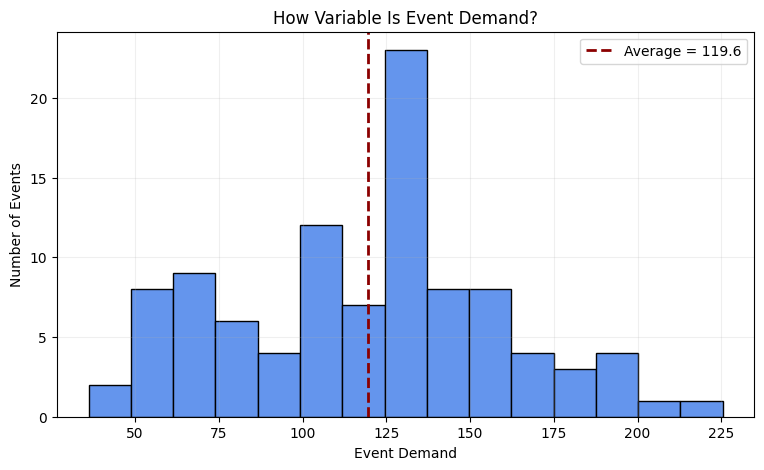


GRAPH 1 - HOW TO READ IT:

The histogram shows how demand is distributed across the simulated events.

Look for:
• Where most events are concentrated.
• Whether demand is highly dispersed.
• Whether some events have unusually high or low demand.

MANAGERIAL QUESTION:
If demand is highly variable, can the organization use the same
capacity plan for every event?



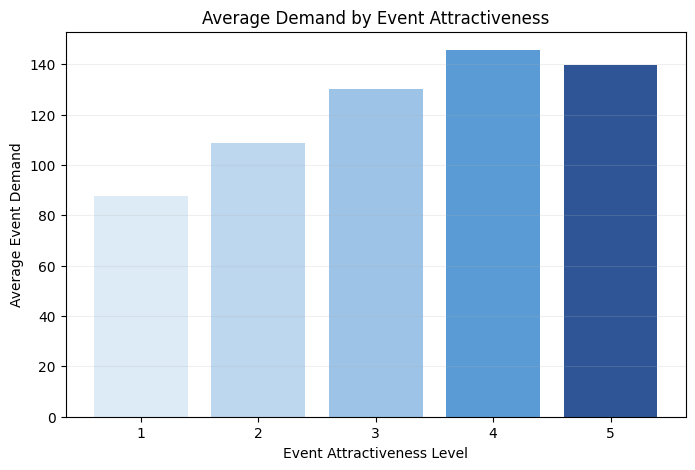


GRAPH 2 - INTERPRETATION:

Compare the average demand for different attractiveness levels.

In this simulated scenario, more attractive events should generally
show higher demand.

MANAGERIAL INSIGHT:
Not every event should necessarily receive the same capacity.
Event characteristics may be useful for segmenting planning decisions.



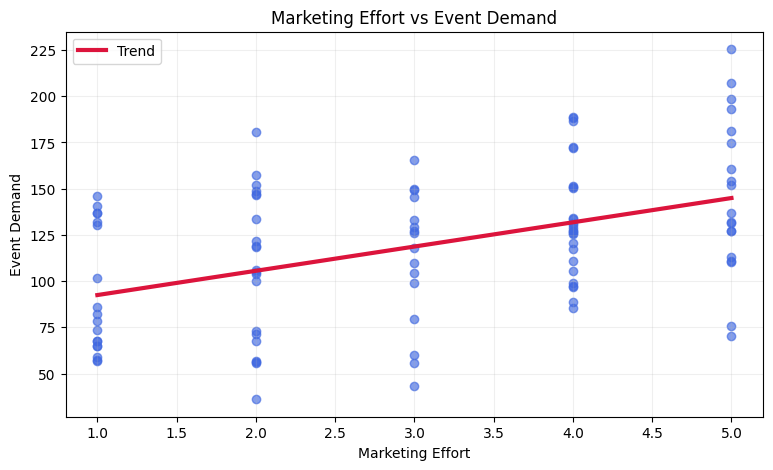


GRAPH 3 - INTERPRETATION:

Each point represents one event.

The red line summarizes the general direction of the relationship.

An upward trend suggests that higher marketing effort is associated
with higher event demand in this simulated dataset.

IMPORTANT:
Association does not automatically mean causation.



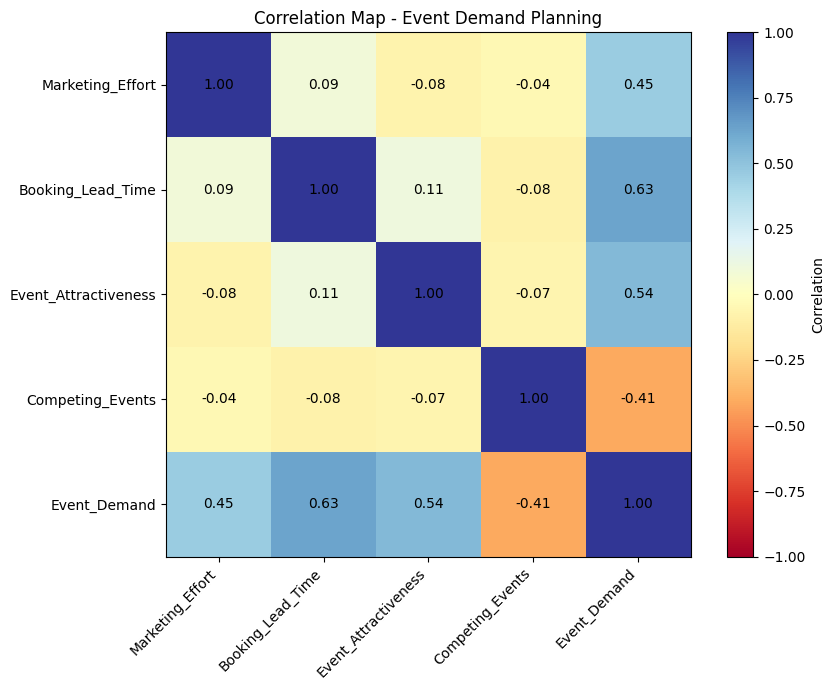


CORRELATIONS WITH EVENT DEMAND:
Event_Demand            1.00
Booking_Lead_Time       0.63
Event_Attractiveness    0.54
Marketing_Effort        0.45
Competing_Events       -0.41
Name: Event_Demand, dtype: float64

GRAPH 4 - INTERPRETATION:

Positive correlation:
The variables tend to move in the same direction.

Negative correlation:
When one variable increases, the other tends to decrease.

Values closer to +1 or -1 indicate stronger linear relationships.

QUESTION:
Which variables deserve further investigation?


LINEAR REGRESSION
R² = 0.915

R² INTERPRETATION:

R² indicates how much of the variability in Event Demand can be
explained by the variables included in this simulated model.

A high R² does NOT prove causality.


STANDARDIZED COEFFICIENTS:
               Variable  Standardized_Coefficient  Absolute_Effect
1     Booking_Lead_Time                     0.507            0.507
2  Event_Attractiveness                     0.496            0.496
0      Marketing_Effort              

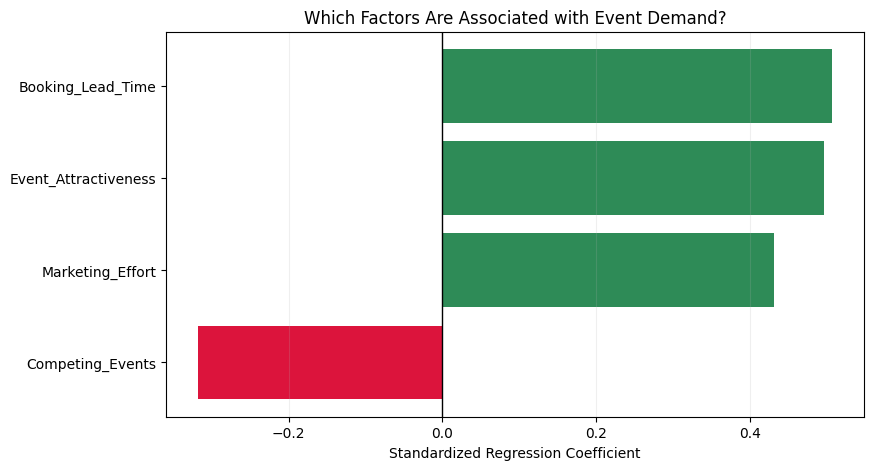


GRAPH 5 - HOW TO READ IT:

GREEN = Positive association with demand.
RED   = Negative association with demand.

Longer bars indicate stronger associations within this
simulated regression model.

This graph helps us move from:

DATA → DRIVERS → POSSIBLE ACTIONS


INTERPRETING THE REGRESSION
Booking_Lead_Time: POSITIVE association with Event Demand.
Event_Attractiveness: POSITIVE association with Event Demand.
Marketing_Effort: POSITIVE association with Event Demand.
Competing_Events: NEGATIVE association with Event Demand.

POSSIBLE IMPROVEMENT ALTERNATIVES
                                Alternative           Approach                                                          Focus
                  A1 - Lean Demand Planning               Lean Standardize planning flow and eliminate unnecessary activities
A2 - Six Sigma Demand Variability Reduction          Six Sigma             Reduce variability and planning errors using DMAIC
         A3 - Quality-Based Planning System Quality Manag

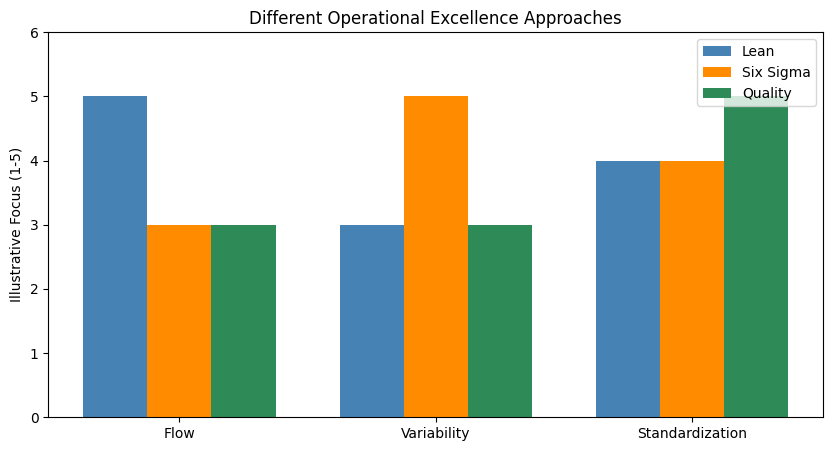


FINAL INTERPRETATION:

The analytical model identified factors associated with Event Demand.

Now the managerial question changes:

WHAT SHOULD WE DO ABOUT IT?

Lean, Six Sigma and Quality Management address the problem
from different perspectives.

We should NOT choose an alternative only because it looks attractive.

NEXT STEP:
Use AHP to compare the alternatives using multiple criteria such as:

• Expected Operational Impact
• Cost
• Implementation Time
• Feasibility
• Sustainability Contribution



In [3]:
# =====================================================================
# TEAM 1 - EVENT DEMAND PLANNING
# ANALYTICS → OPERATIONAL EXCELLENCE → IMPROVEMENT ALTERNATIVES → AHP
# =====================================================================
#
# ONE ROW = One simulated event
#
# Y = Event_Demand
#
# X1 = Marketing_Effort
# X2 = Booking_Lead_Time
# X3 = Event_Attractiveness
# X4 = Competing_Events
#
# IMPORTANT:
# All data are simulated for learning purposes.
# =====================================================================


# =====================================================================
# 1. IMPORT LIBRARIES
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score


# =====================================================================
# 2. BUSINESS PROBLEM
# =====================================================================

print("=" * 75)
print("EVENT DEMAND PLANNING")
print("=" * 75)

print("""
BUSINESS PROBLEM:
The organization has difficulty anticipating event demand,
which complicates capacity and resource planning.

MANAGERIAL QUESTION:
Which factors are associated with changes in event demand?

TARGET VARIABLE (Y):
Event Demand
""")


# =====================================================================
# 3. CREATE SIMULATED DATA
# =====================================================================

np.random.seed(42)

n = 100

# Marketing effort: 1 = very low, 5 = very high
marketing = np.random.randint(1, 6, n)

# Booking lead time: 1-30 days
booking = np.random.randint(1, 31, n)

# Event attractiveness: 1 = low, 5 = high
attractiveness = np.random.randint(1, 6, n)

# Number of competing events: 0-5
competition = np.random.randint(0, 6, n)


# Create Y
#
# Simulated assumptions:
# Marketing ↑       → Demand ↑
# Booking time ↑    → Demand ↑
# Attractiveness ↑  → Demand ↑
# Competition ↑     → Demand ↓

demand = (
    30
    + 12 * marketing
    + 2 * booking
    + 15 * attractiveness
    - 8 * competition
    + np.random.normal(0, 12, n)
)

demand = np.maximum(demand, 0)


# =====================================================================
# 4. CREATE DATABASE
# =====================================================================

df = pd.DataFrame({
    "Marketing_Effort": marketing,
    "Booking_Lead_Time": booking,
    "Event_Attractiveness": attractiveness,
    "Competing_Events": competition,
    "Event_Demand": demand
})

print("\nFIRST 10 OBSERVATIONS:")
print(df.head(10).round(2))


# =====================================================================
# 5. DESCRIPTIVE ANALYTICS
# =====================================================================

print("\n" + "=" * 75)
print("DESCRIPTIVE ANALYTICS")
print("=" * 75)

print(df.describe().round(2))

mean_y = df["Event_Demand"].mean()
std_y = df["Event_Demand"].std()

print(f"\nAverage Event Demand: {mean_y:.1f}")
print(f"Standard Deviation: {std_y:.1f}")

print("""
INTERPRETATION:
The average represents the typical demand in our simulated events.
The standard deviation tells us how much demand varies between events.

Operational Excellence is interested not only in average performance,
but also in VARIABILITY and PREDICTABILITY.
""")


# =====================================================================
# 6. GRAPH 1 - DISTRIBUTION OF EVENT DEMAND
# =====================================================================

plt.figure(figsize=(9, 5))

plt.hist(
    df["Event_Demand"],
    bins=15,
    color="cornflowerblue",
    edgecolor="black"
)

plt.axvline(
    mean_y,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Average = {mean_y:.1f}"
)

plt.title("How Variable Is Event Demand?")
plt.xlabel("Event Demand")
plt.ylabel("Number of Events")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

print("""
GRAPH 1 - HOW TO READ IT:

The histogram shows how demand is distributed across the simulated events.

Look for:
• Where most events are concentrated.
• Whether demand is highly dispersed.
• Whether some events have unusually high or low demand.

MANAGERIAL QUESTION:
If demand is highly variable, can the organization use the same
capacity plan for every event?
""")


# =====================================================================
# 7. GRAPH 2 - DEMAND BY EVENT ATTRACTIVENESS
# =====================================================================

average_by_attractiveness = (
    df.groupby("Event_Attractiveness")["Event_Demand"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    average_by_attractiveness.index,
    average_by_attractiveness.values,
    color=["#DDEBF7", "#BDD7EE", "#9DC3E6", "#5B9BD5", "#2F5597"]
)

plt.title("Average Demand by Event Attractiveness")
plt.xlabel("Event Attractiveness Level")
plt.ylabel("Average Event Demand")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis="y", alpha=0.2)

plt.show()

print("""
GRAPH 2 - INTERPRETATION:

Compare the average demand for different attractiveness levels.

In this simulated scenario, more attractive events should generally
show higher demand.

MANAGERIAL INSIGHT:
Not every event should necessarily receive the same capacity.
Event characteristics may be useful for segmenting planning decisions.
""")


# =====================================================================
# 8. GRAPH 3 - MARKETING VS DEMAND
# =====================================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    df["Marketing_Effort"],
    df["Event_Demand"],
    color="royalblue",
    alpha=0.65
)

# Trend line
z = np.polyfit(
    df["Marketing_Effort"],
    df["Event_Demand"],
    1
)

p = np.poly1d(z)

x_line = np.linspace(1, 5, 100)

plt.plot(
    x_line,
    p(x_line),
    color="crimson",
    linewidth=3,
    label="Trend"
)

plt.title("Marketing Effort vs Event Demand")
plt.xlabel("Marketing Effort")
plt.ylabel("Event Demand")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

print("""
GRAPH 3 - INTERPRETATION:

Each point represents one event.

The red line summarizes the general direction of the relationship.

An upward trend suggests that higher marketing effort is associated
with higher event demand in this simulated dataset.

IMPORTANT:
Association does not automatically mean causation.
""")


# =====================================================================
# 9. GRAPH 4 - CORRELATION HEATMAP
# =====================================================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))

plt.imshow(
    corr,
    cmap="RdYlBu",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):

        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Map - Event Demand Planning")
plt.tight_layout()

plt.show()


print("\nCORRELATIONS WITH EVENT DEMAND:")

print(
    corr["Event_Demand"]
    .sort_values(ascending=False)
    .round(2)
)

print("""
GRAPH 4 - INTERPRETATION:

Positive correlation:
The variables tend to move in the same direction.

Negative correlation:
When one variable increases, the other tends to decrease.

Values closer to +1 or -1 indicate stronger linear relationships.

QUESTION:
Which variables deserve further investigation?
""")


# =====================================================================
# 10. MULTIPLE LINEAR REGRESSION
# =====================================================================

X = df[
    [
        "Marketing_Effort",
        "Booking_Lead_Time",
        "Event_Attractiveness",
        "Competing_Events"
    ]
]

y = df["Event_Demand"]

model = LinearRegression()

model.fit(X, y)

prediction = model.predict(X)

r2 = r2_score(y, prediction)


print("\n" + "=" * 75)
print("LINEAR REGRESSION")
print("=" * 75)

print(f"R² = {r2:.3f}")

print("""
R² INTERPRETATION:

R² indicates how much of the variability in Event Demand can be
explained by the variables included in this simulated model.

A high R² does NOT prove causality.
""")


# =====================================================================
# 11. STANDARDIZED REGRESSION
# =====================================================================
#
# We standardize the variables because they use different scales.
#
# This makes the coefficient comparison more useful for teaching.
# =====================================================================

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(
    y.values.reshape(-1, 1)
).ravel()

standard_model = LinearRegression()

standard_model.fit(X_scaled, y_scaled)

results = pd.DataFrame({
    "Variable": X.columns,
    "Standardized_Coefficient": standard_model.coef_
})

results["Absolute_Effect"] = (
    results["Standardized_Coefficient"].abs()
)

results = results.sort_values(
    "Absolute_Effect",
    ascending=False
)

print("\nSTANDARDIZED COEFFICIENTS:")
print(results.round(3))


# =====================================================================
# 12. GRAPH 5 - DRIVER IMPORTANCE
# =====================================================================

plot_results = results.sort_values(
    "Standardized_Coefficient"
)

colors = [
    "crimson" if value < 0 else "seagreen"
    for value in plot_results["Standardized_Coefficient"]
]

plt.figure(figsize=(9, 5))

plt.barh(
    plot_results["Variable"],
    plot_results["Standardized_Coefficient"],
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title("Which Factors Are Associated with Event Demand?")
plt.xlabel("Standardized Regression Coefficient")
plt.grid(axis="x", alpha=0.2)

plt.show()


print("""
GRAPH 5 - HOW TO READ IT:

GREEN = Positive association with demand.
RED   = Negative association with demand.

Longer bars indicate stronger associations within this
simulated regression model.

This graph helps us move from:

DATA → DRIVERS → POSSIBLE ACTIONS
""")


# =====================================================================
# 13. AUTOMATIC INTERPRETATION
# =====================================================================

print("\n" + "=" * 75)
print("INTERPRETING THE REGRESSION")
print("=" * 75)

for _, row in results.iterrows():

    variable = row["Variable"]
    coefficient = row["Standardized_Coefficient"]

    if coefficient > 0:

        print(
            f"{variable}: POSITIVE association with Event Demand."
        )

    else:

        print(
            f"{variable}: NEGATIVE association with Event Demand."
        )


# =====================================================================
# 14. FROM DRIVERS TO IMPROVEMENT ALTERNATIVES
# =====================================================================

alternatives = pd.DataFrame({

    "Alternative": [
        "A1 - Lean Demand Planning",
        "A2 - Six Sigma Demand Variability Reduction",
        "A3 - Quality-Based Planning System"
    ],

    "Approach": [
        "Lean",
        "Six Sigma",
        "Quality Management"
    ],

    "Focus": [
        "Standardize planning flow and eliminate unnecessary activities",
        "Reduce variability and planning errors using DMAIC",
        "Strengthen planning criteria, checkpoints and data quality"
    ]
})

print("\n" + "=" * 75)
print("POSSIBLE IMPROVEMENT ALTERNATIVES")
print("=" * 75)

print(alternatives.to_string(index=False))


# =====================================================================
# 15. GRAPH 6 - CONNECTION TO OPERATIONAL EXCELLENCE
# =====================================================================
#
# IMPORTANT:
# These scores DO NOT represent the AHP result.
#
# They are ONLY a visual teaching profile of how the three
# methodologies focus on different improvement dimensions.
# =====================================================================

dimensions = [
    "Flow",
    "Variability",
    "Standardization"
]

lean_profile = [5, 3, 4]
six_sigma_profile = [3, 5, 4]
quality_profile = [3, 3, 5]

x = np.arange(len(dimensions))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    lean_profile,
    width,
    label="Lean",
    color="steelblue"
)

plt.bar(
    x,
    six_sigma_profile,
    width,
    label="Six Sigma",
    color="darkorange"
)

plt.bar(
    x + width,
    quality_profile,
    width,
    label="Quality",
    color="seagreen"
)

plt.xticks(x, dimensions)
plt.ylabel("Illustrative Focus (1-5)")
plt.title("Different Operational Excellence Approaches")
plt.legend()
plt.ylim(0, 6)

plt.show()


print("""
FINAL INTERPRETATION:

The analytical model identified factors associated with Event Demand.

Now the managerial question changes:

WHAT SHOULD WE DO ABOUT IT?

Lean, Six Sigma and Quality Management address the problem
from different perspectives.

We should NOT choose an alternative only because it looks attractive.

NEXT STEP:
Use AHP to compare the alternatives using multiple criteria such as:

• Expected Operational Impact
• Cost
• Implementation Time
• Feasibility
• Sustainability Contribution
""")